1.6 Food Demand System Estimation
-

This project estimates a food demand system using household expenditure and demographic data. The goal is to understand how spending differs across food categories and how consumption changes with household need, including household size, age structure, and gender composition.

Project Overview: 
- $\mathbf{Data}$: Household food expenditure and demographic characteristics
- $\mathbf{Method}$: Demand system estimation using log expenditures
- $\mathbf{Goal}$: Study how food demand varies with income and household composition

In [4]:
%pip install -r requirements-estimation.txt

  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached cfedemands-0.8.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached ligonlibrary-0.2.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached consumerdemands-0.5.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached gspread_pandas-3.3.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached python_magic-0.4.27-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached thefuzz-0.22.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached rapidfuzz-3.14.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
Using cached cfedemands-0.8.2-py3-none-any.whl (98 kB)
Using cached ligonlibrary-0.2.0-py3-none-any.whl (19 kB)
Using cached consumerdemands-0.5.0-py3-none-any.whl (14 kB)
Using cached gspread_pandas-3.3.

In [5]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
from eep153_tools.sheets import read_sheets

# Data


$\textbf{Population of Interest}$: Nigeria

We will be using the following spreadsheet for our data: https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303


In [7]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [8]:
import pandas as pd
import numpy as np

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = np.log(x)

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

In [9]:
#We are only doing one year & quarter for now, but we can incorporate the other sheets later on to get a holistic undestanding
y, d = prepare_data(NG_URL, "Food Expenditures (2016Q1)")

In [10]:
d.head()

k                        Female 00-03  Female 04-08  Female 09-13  \
i     t      m                                                      
10001 2010Q3 south east             1             0             0   
      2011Q1 south east             1             0             0   
      2012Q3 south east             1             0             0   
      2013Q1 south east             0             1             0   
      2015Q3 south east             0             1             0   

k                        Female 14-18  Female 19-30  Female 31-50  Female 51+  \
i     t      m                                                                  
10001 2010Q3 south east             0             1             2           0   
      2011Q1 south east             0             1             2           0   
      2012Q3 south east             0             1             2           0   
      2013Q1 south east             0             1             2           0   
      2015Q3 south east             0             0             2           0   

k                        Female NA  Male 00-03  Male 04-08  Male 09-13  \
i     t      m                                                           
10001 2010Q3 south east          0           0           0           0   
      2011Q1 south east          0           0           0           0   
      2012Q3 south east          0           0           0           0   
      2013Q1 south east          0           1           0           0   
      2015Q3 south east          1           1           0           0   

k                        Male 14-18  Male 19-30  Male 31-50  Male 51+  \
i     t      m                                                          
10001 2010Q3 south east           0           1           2         0   
      2011Q1 south east           0           1           2         0   
      2012Q3 south east           0           0           1         2   
      2013Q1 south east           0           0           1         2   
      2015Q3 south east           0           0           0         1   

k                        Male NA  log HSize  
i     t      m                               
10001 2010Q3 south east        0   1.945910  
      2011Q1 south east        0   1.945910  
      2012Q3 south east        0   1.945910  
      2013Q1 south east        0   2.079442  
      2015Q3 south east        2   2.079442

In [11]:
y.head()

,,j,Apples,Avocado pear,Baby milk powder,Bananas,Beef,Beer,Biscuits,Bottled water,Bread,Brown beans,...,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Watermelon,Wheat flour,White beans,Wild game meat,Yam flour,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,NaN,NaN,NaN,4.210878,7.600902,NaN,4.248495,NaN,5.991465,NaN,...,5.08136,NaN,NaN,5.005598,NaN,NaN,5.521461,NaN,NaN,6.164674
10002,2016Q1,south east,4.787492,NaN,NaN,4.835033,6.907755,NaN,5.472671,5.703782,6.396930,5.521461,...,NaN,NaN,NaN,5.703782,5.422525,NaN,NaN,NaN,NaN,6.164674
10003,2016Q1,south east,NaN,NaN,NaN,4.605170,6.907755,NaN,3.688879,5.010635,5.603241,5.521461,...,NaN,5.192957,5.298317,5.181162,NaN,NaN,NaN,NaN,NaN,6.159585
10004,2016Q1,south east,NaN,NaN,NaN,NaN,6.907755,NaN,4.248495,NaN,5.577266,5.521461,...,NaN,5.010635,5.010635,5.181162,NaN,NaN,NaN,NaN,NaN,5.471527
10005,2016Q1,south east,NaN,NaN,NaN,NaN,6.907755,NaN,4.605170,NaN,5.991465,5.703782,...,NaN,5.010635,5.010635,5.586627,NaN,NaN,NaN,NaN,NaN,6.159585


Estimation 
-


Let $y_i^j$ be log expendicture on food $j$ by household $i$ at a particular time. We want to estimate a regression that takes the form: 

$y_i^j = A^j(p) + \gamma_j' d_i + \beta_j w_i + \zeta_i^j$
-



In [12]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

Basic Estimation
-

In [13]:
from cfe import Regression

result = Regression(y=y,d=d)

In [14]:
result.predicted_expenditures()

i       t       m              j                    
10001   2016Q1  south east     Bananas                   224.848660
                               Beef                      953.012075
                               Biscuits                   86.682347
                               Bread                     416.795418
                               Brown beans               318.895615
                                                           ...     
370040  2016Q1  north central  Tomato puree (canned)     158.065816
                               Tomatoes                  170.388515
                               Watermelon                292.245199
                               White beans               473.464052
                               Yam--roots               1139.399240
Length: 195224, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

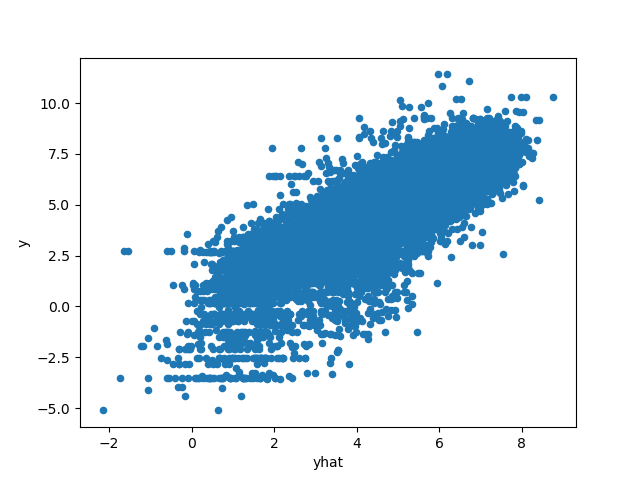

In [15]:
%matplotlib widget
df = pd.DataFrame({'y':y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')

Interpretation of Results
-

The table tells us what the model predicts households will spend, and the plot tells us how close those predictions are to actual spending

# Parameters: 


(Relative) Income Elasticity:
-


 
$\beta$ coefficients govern how income elastic different goods are (higher values means more elastic). These are also called Frisch elasticities

In [16]:
result.get_beta().sort_values()

j
Pineapples                              0.110004
Malt drinks                             0.175755
Kola nut                                0.175997
Ogbono                                  0.188046
Groundnut oil                           0.202537
Palm oil                                0.216506
Chicken                                 0.222732
Brown beans                             0.236294
Pawpaw                                  0.246758
Soft drinks (Coca Cola, spirit, etc)    0.248809
Plantains                               0.278037
Beef                                    0.283670
Gari                                    0.284542
Fish--frozen                            0.287839
Pepper                                  0.323108
Garden eggs/egg plant                   0.325827
Other vegetables (fresh or canned)      0.329848
Eggs                                    0.343187
Tomato puree (canned)                   0.346697
Watermelon                              0.356503
White beans       

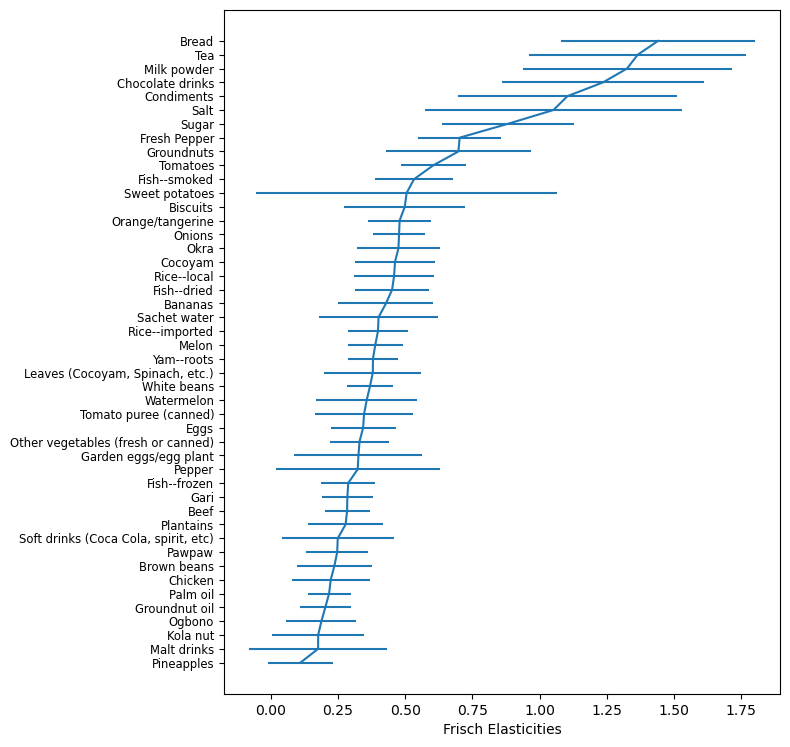

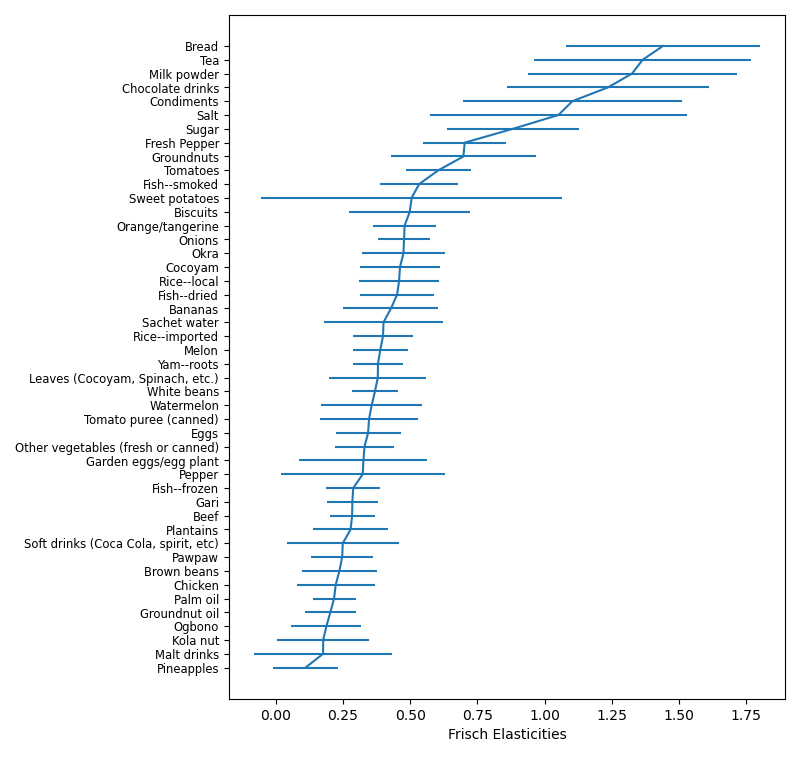

In [17]:
result.graph_beta()

Interpretation of $\beta$ values 
-

Goods with higher $\beta$ values are more responsive to income, while goods with lower $\beta$ values are less responsive. This means that when a household has more resources to spend, it tends to increase spending more on goods with higher 

Some specific examples from above:

- Bread ($\beta$≈1.44), Tea ($\beta$≈1.36), and Milk powder ($\beta$≈1.33) are among the most income-responsive goods, meaning spending on these tends to rise more as household resources increase.
- Chocolate drinks ($\beta$≈1.24), Condiments ($\beta$≈1.10), and Salt ($\beta$≈1.05) are also relatively income-responsive.
- Pineapples (β≈0.11) and Malt drinks (β≈0.18) are among the least income-responsive goods, meaning spending on these changes less as household resources rise.

# Demand and Household Composition

$\gamma_{j}$ parameters in the regression are the effects of household composition on demand.

In [18]:
result.gamma

k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Female NA,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,Male NA,log HSize,Constant
j,,,,,,,,,,,,,,,,,,
Bananas,-0.073013,0.070019,0.096545,0.108353,0.150393,0.165893,0.150281,0.024814,0.046503,0.034176,0.083921,0.113344,0.053774,0.108180,0.085294,-0.017933,0.047383,5.215043
Beef,-0.004548,0.005960,-0.018177,0.003144,0.081884,0.020772,0.008627,-0.022642,-0.023783,0.044092,-0.007670,0.034180,0.047685,0.109358,0.146129,-0.042846,0.190226,6.759567
Biscuits,-0.001854,0.055226,-0.021374,0.025799,-0.015120,0.051166,-0.135300,-0.010417,0.108349,-0.043725,-0.052534,-0.020993,0.024836,0.108465,0.053022,-0.017397,0.340834,3.994985
Bread,-0.108352,-0.148544,-0.186654,-0.056737,-0.017390,-0.023116,0.032171,-0.093828,-0.048818,-0.011707,-0.048302,0.003657,-0.196795,-0.145219,-0.046244,-0.115196,0.624720,5.507083
Brown beans,-0.009496,0.036456,0.040938,-0.045043,0.062893,0.083456,0.137873,-0.030332,-0.058265,0.108094,0.029861,-0.029247,0.057962,0.116353,-0.011903,-0.029039,0.361071,5.874225
Chicken,0.029744,0.111941,0.057465,-0.003257,0.095947,0.139365,0.078267,0.017335,0.007504,0.051729,0.048046,0.150360,0.074479,-0.011283,0.185726,0.021229,-0.227989,7.152837
Chocolate drinks,-0.011696,-0.018085,-0.007632,0.177774,0.047536,0.097233,0.092393,-0.003222,0.058936,0.037790,-0.098449,0.027890,0.127923,0.131830,0.098284,-0.057528,0.362924,5.347818
Cocoyam,0.017506,-0.009624,0.022849,-0.000189,0.098178,0.091565,0.054931,0.015511,-0.003198,-0.059145,0.086451,-0.029486,0.044738,0.141889,0.133776,-0.029391,0.117694,5.365803
Condiments,0.089226,0.108974,0.175919,-0.038493,0.134788,0.356103,0.227464,-0.075642,0.052687,-0.021934,0.095180,0.117202,0.237487,0.157345,-0.011707,-0.071871,0.353454,4.107178


Interpretation of $\gamma$ values
-

The $\gamma$ coefficients show how household composition affects demand for each food. A positive $\gamma$ means that households with more people in that demographic category tend to spend more on that good, while a negative $\gamma$ means they tend to spend less. In simple terms, these values tell us how food demand changes depending on who lives in the household.

Some specfic values from above: 
- Bananas: the coefficient on Female 31–50 is positive ($\gamma$≈0.066), while the coefficient on Male 14–18 is negative ($\gamma$≈−0.094). This suggests banana spending tends to be higher in households with more adult women ages 31 to 50, but lower in households with more males ages 14 to 18.
- Cassava (root): the coefficient on Female 09–13 is positive ($\gamma$≈0.084), while the coefficients on Male 00–03 and Male 31–50 are negative ($\gamma$≈−0.206 and $\gamma$≈−0.373). This suggests cassava root spending tends to be higher in households with more girls ages 9 to 13, but lower in households with more very young boys or adult men ages 31 to 50.

Created by: Natalie Cornejo, Inaaya Hasham, Kita Hu, Benjamin Zacharia, & Tanaisha Mistry